# MLP Autoencoder Model — Feature Corrrelation Anomaly Detection

This notebook implements a standard feed forward MLP Autoencoder to learn the "normal" state of robot sensor data. This model treats the entire sensor window as a single vector, focusing on the correlation between different sensors across a fixed timeframe.

### Reproducibility
1. Preprocessing: Run `00_data_analysis.ipynb` and `01_data_preparation.ipynb` in order to generate required `splits.npz`.
2. Data shape: This model expects flattened inputs of shape 300 (20 timesteps x 15 features).

# output incomplete

### Output Artefacts
| File | Description |
|------|-------------|
| `../model/lstm_autoencoder/lstm_autoencoder.pth` | Final trained model weights |
| `../figures/lstm_autoencoder/loss_curve.png` | Training vs Validation MSE convergence |
| `../figures/lstm_autoencoder/error_distribution.png` | Histogram of reconstruction errors used for threshold calibration |
| `../figures/lstm_autoencoder/confusion_matrix.png` | Final evaluation results (cycle-level) on test set |


### 1. Setting up the device

In [20]:
import json
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

DATA_PATH = Path("../data/processed/splits.npz")
MLPAUTO_MODEL_PATH = Path("../model/mlp_autoencoder/mlp_autoencoder.pth")

Using device: cuda


### 2. Load processed data

In [3]:
# Load data
data = np.load(DATA_PATH)

# Convert to PyTorch Tensors (and ensure float32)
X_train = torch.tensor(data['X_train'], dtype=torch.float32)
X_val   = torch.tensor(data['X_val'], dtype=torch.float32)

# Create DataLoaders
# batch size = 128 for good balance of memory and speed
train_loader = DataLoader(TensorDataset(X_train), batch_size=128, shuffle=True)
val_loader   = DataLoader(TensorDataset(X_val), batch_size=128)

print(f"Loaded {X_train.shape[0]} training samples and {X_val.shape[0]} validation samples.")

Loaded 204854 training samples and 43865 validation samples.


### 3. MLP Autoencoder Architecture
The model uses a symmetric feed forward encorder-decoder structure to learn spatial correlations between the robot sensors.

**Encoder:** consists of 2 fully connected linear layers.
- **Input:** Flattened vector of 300 features (20 timesteps x 15 sensors)
- **Function:** Compresses the 300 features down to a 32-dimensional bottleneck (embedding) to act as a summary of the robot state in that specific time window.

**Decoder:** consists of 2 fully connected layers that mirrors Encoder.
- **Function:** Attempts to expand the 32-dimensional embedding back into the original 300 feature sequence.
- **Output:** A reconstructed version of input window 20 x 15.
  
**Logic:** If the model can reconstruct the input with low error then the robot movement is considered as **"Normal"**. If the reconstruction error is high then the movement will be flagged as an **"Anomaly"**.

**Bottleneck effect:** By forcing 300 numbers through the 32-number gate, we prevent the model from memorising the data and force it to learn the core relationships between the 15 sensors, effectively filtering out noise and focus on the mechanical patterns of the robot.

In [4]:
class MLPAutoencoder(nn.Module):
    def __init__(self, input_dim=300):
        super(MLPAutoencoder, self).__init__()
        
        # Ecoder: compressing the 300 numbers down to 32
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 32), # bottleneck is here
            nn.ReLU()
        )
        
        # Decoder: reconstruct the 300 numbers back to the original
        self.decoder = nn.Sequential(
            nn.Linear(32, 128),
            # dropout layer if it overfits
            nn.ReLU(),
            nn.Linear(128, input_dim) 
        )

    def forward(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded

model = MLPAutoencoder().to(device)
print(model)

MLPAutoencoder(
  (encoder): Sequential(
    (0): Linear(in_features=300, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=32, bias=True)
    (3): ReLU()
  )
  (decoder): Sequential(
    (0): Linear(in_features=32, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=300, bias=True)
  )
)


### 4. Loss Function and Optimiser
To train the model to reconstruct the robot sensor data accurately, we use the following configuration:

**Loss function: Mean Squared Error (MSE)**
- We minimise the squared difference between the input sequence and reconstructed sequence. The model compares all 300 data points simultaneously.

**Optimiser: Adam**
- The Adam optimiser is used with a learning rate = 0.001. It is selected for its efficiency and ability to adapt the learning rate for each parameter, making it ideal for MLP architectures as the model can converge quickly on complex correlations between the different joints of the robot.

In [5]:
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

### 5. Training Loop

The training process is designed to iteratively minimise the reconstruction error of the robot sensor vectors. Training exclusively on normal operational data allows the model to learn to compress and reconstruct healthy patterns while failing to do the same for anomalous patterns.

**Key components:**
- **Epochs and Iterations:** The model is trained for 20 epochs and in each epoch, the data is processed in batches to ensure stable gradient updates and efficient memory usage on the GPU.

- **Backpropagation:** We use the standard PyTorch workflow.
  1. `optimizer.zero_grad()`: resets the gradients to prevent accumulating of previous batches.
  2. `loss.backward()`: computes the gradient of the MSE loss wrt model parameters.
  3. `optimizer.step()`: updates the linear layer weights based on computed gradients.

- **Validation:** After every epoch, the model switches to `eval()` mode. We use gradient calculation `torch.no_grad()` to deactivate the gradient tracking engine and evaluate the loss on a separate validation split without modifying the weights. This helps monitor the model's ability to generalise and detect early overfitting.

- **Model persistence:** Weights are saved to `model/mlp_autoencoder/mlp_autoencoder.pth` for reproducibility without retraining.

In [ ]:
epochs = 20
history = {'train_loss': [], 'val_loss': []}

print("Starting Training...")
for epoch in range(epochs):
    model.train()
    train_running_loss = 0.0
    
    for batch in train_loader:
        inputs = batch[0].to(device)
        
        # Reset gradients
        optimizer.zero_grad()
        
        # Forward pass
        outputs = model(inputs)
        loss = criterion(outputs, inputs)
        
        # Backward pass
        loss.backward()
        optimizer.step()
        
        train_running_loss += loss.item()
    
    # Validation
    model.eval()
    val_running_loss = 0.0
    with torch.no_grad():
        for batch in val_loader:
            inputs = batch[0].to(device)
            outputs = model(inputs)
            v_loss = criterion(outputs, inputs)
            val_running_loss += v_loss.item()
            
    # Save stats
    epoch_train_loss = train_running_loss / len(train_loader)
    epoch_val_loss = val_running_loss / len(val_loader)
    history['train_loss'].append(epoch_train_loss)
    history['val_loss'].append(epoch_val_loss)
    
    print(f"Epoch [{epoch+1}/{epochs}] - Train Loss: {epoch_train_loss:.6f} | Val Loss: {epoch_val_loss:.6f}")

# Directory name from model path
model_dir = os.path.dirname(MLPAUTO_MODEL_PATH) 

# Create directory if it doesnt exist
os.makedirs(model_dir, exist_ok=True)

# Save history to JSON
history_path = os.path.join(model_dir, "history.json")
with open(history_path, "w") as f:
    json.dump(history, f)

# Save trained weights for reproducibility
torch.save(model.state_dict(), MLPAUTO_MODEL_PATH)

print(f"Finished! Model and history saved to {model_dir}")

Starting Training...
Epoch [1/20] - Train Loss: 0.055119 | Val Loss: 0.055311
Epoch [2/20] - Train Loss: 0.055078 | Val Loss: 0.055516
Epoch [3/20] - Train Loss: 0.054976 | Val Loss: 0.055680
Epoch [4/20] - Train Loss: 0.054875 | Val Loss: 0.055127
Epoch [5/20] - Train Loss: 0.054889 | Val Loss: 0.054929
Epoch [6/20] - Train Loss: 0.054771 | Val Loss: 0.055437
Epoch [7/20] - Train Loss: 0.054714 | Val Loss: 0.054993
Epoch [8/20] - Train Loss: 0.054610 | Val Loss: 0.055127
Epoch [9/20] - Train Loss: 0.054581 | Val Loss: 0.054715
Epoch [10/20] - Train Loss: 0.054478 | Val Loss: 0.054854
Epoch [11/20] - Train Loss: 0.054342 | Val Loss: 0.054622
Epoch [12/20] - Train Loss: 0.054274 | Val Loss: 0.054566
Epoch [13/20] - Train Loss: 0.054208 | Val Loss: 0.054596
Epoch [14/20] - Train Loss: 0.054129 | Val Loss: 0.054360
Epoch [15/20] - Train Loss: 0.054066 | Val Loss: 0.054164
Epoch [16/20] - Train Loss: 0.054008 | Val Loss: 0.054079
Epoch [17/20] - Train Loss: 0.053980 | Val Loss: 0.054064
Ep

------
### 6. Visualising Model (MLP Autoencoder)

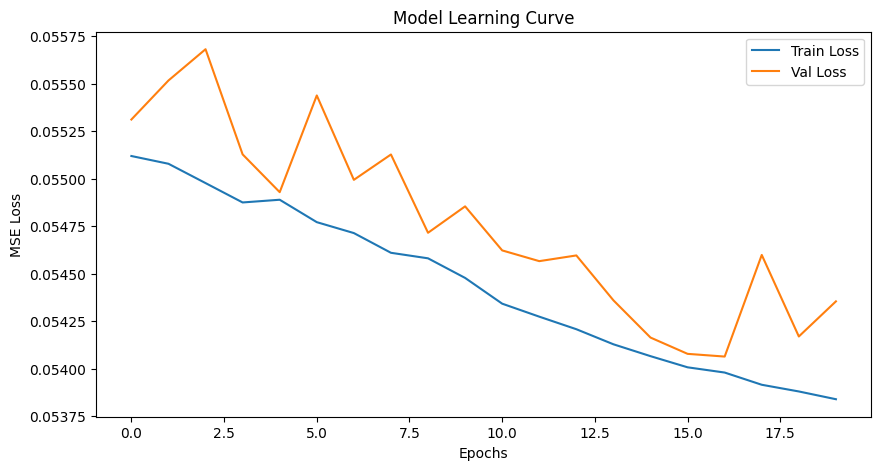

In [17]:
# Path for training history to ensure plot reproducibility without retraining
history_path = "../model/mlp_autoencoder/history.json"

with open(history_path, "r") as f:
    history = json.load(f)

plt.figure(figsize=(10, 5))
plt.plot(history['train_loss'], label='Train Loss')
plt.plot(history['val_loss'], label='Val Loss')
plt.title('Model Learning Curve')
plt.xlabel('Epochs')
plt.ylabel('MSE Loss')
plt.legend()

# Save loss curve figure
plt.savefig('../figures/mlp_autoencoder/loss_curve.png')
plt.show()

### 7. Analysing the curve

The figure above illustrates the learning curve for both the training and validation sets over 20 epochs.

**Observations:**
- **Learning:** The train loss (blue line) is consistently decreasing, showing that the MLP is updating its weights to better reconstruct sensor data over time.

- **Noisy Validation:** The validation loss (orange line) is jittery compared to the smooth training line. This shows the model is sensitive to specific batches in the validation set and as it is still following the train loss downwards, it means it is not overfitting.

- **Generalisation Gap:** There is a consistent gap between the validation and training loss. As the gap does not widen over time, it shows the architecture is at a good size, not too complex or simple.

Spikes in validation loss suggests that certain "normal" cycles in the validation data might look slightly different from the training data, causing the model to be confused temporarily.

-----
-----
### 8. Threshold Calibration Strategy

Since the MLP learning curve was jittery, we must define a value high enough to ignore the validation spikes but low enough to catch a real malfunction. The MLP Autoencoder outputs a continuous MSE so we will define a threshold to separate normal behaviour from anomalies.

- **Metric:** We use cycle-level aggregation to calculate MSE for each 300-feature window. The `max` error is observed withina complete robot cycle as the representative value for that task.

- **Calibration:** Threshold is set based on the normal validation set. We identify the maximum cycle-level error observed during healthy operations (threshold = max(validation_errors)). This approach prioritises a **zero false alarm rate**, preventing unnecessary costly production halts while maintaining sensitivity to significant mechanical deviations.

Suggested Threshold based on Normal Validation data: 0.2801


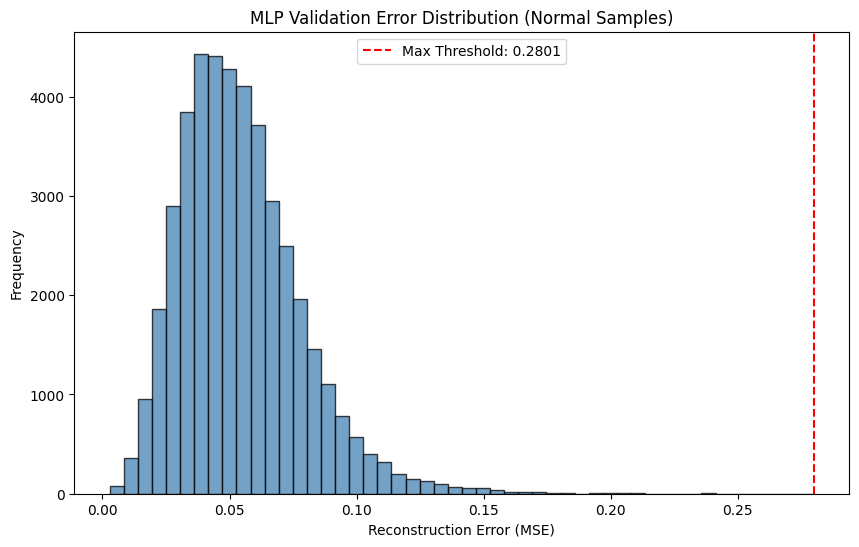

In [18]:
# Calibration logic
model.eval()
val_errors = []

with torch.no_grad():
    for batch in val_loader:

        inputs = batch[0].to(device)
        
        # Ensure data is flattened to (batch_size, 300)
        # .view(inputs.size(0), -1) handles this
        inputs_flat = inputs.view(inputs.size(0), -1)
        
        # Pass through MLP
        recons = model(inputs_flat)
        
        # Calculate MSE per sample in the batch, dim=1 is the 300 features
        batch_mse = torch.mean((recons - inputs_flat)**2, dim=1)
        
        val_errors.extend(batch_mse.cpu().numpy())

# Convert to numpy array for thresholding
val_errors = np.array(val_errors)

# Threshold based on max validation
threshold = np.max(val_errors) 
print(f"Suggested Threshold based on Normal Validation data: {threshold:.4f}")

# Plot
plt.figure(figsize=(10, 6))
plt.hist(val_errors, bins=50, alpha=0.75, color='steelblue', edgecolor='black')
plt.axvline(x=threshold, color='r', linestyle='--', label=f'Max Threshold: {threshold:.4f}')
plt.xlabel('Reconstruction Error (MSE)')
plt.ylabel('Frequency')
plt.title('MLP Validation Error Distribution (Normal Samples)')
plt.legend()

# Save histogram figure
os.makedirs('../figures/mlp_autoencoder/', exist_ok=True)
plt.savefig('../figures/mlp_autoencoder/error_distribution.png')
plt.show()

### 9. Analysing the histogram

Most the normal data is between 0.03 and 0.08 but there is long tail. The suggesteed threshold of 0.2801 is very conservative, way past the visible bars of the distribution.

**Observations:**
- **Error concentration:** Majority of normal cycles are reconstructed with an error under 0.10. This shows the MLP is generally good at capturing the robot's movements.

- **Conservative threshold:** The threshold of 0.2801 shows the model will only flag an anomaly if the error is significantly worse than the worst that the model saw in the normal set. This is ideal for the zero false alarm strategy.

- **Near miss:** There are tiny bars between 0.15 and 0.25. These are the outliers where though considered normal, they are still unusual versions of healthy behaviour.

### 10. Determining Optimal Threshold

**Strategy 1: Zero False Alarm Baseline (Max-Val)**

We utilise the Maximum MSE produced by the model on the Normal Validation set.

- **Logic:** The model was trained exclusively on healthy data so the worst reconstruction of a healthy sample represents the definitive upper bound of normal behaviour.
- **Result:** threshold of **0.2801**
- **Goal:** Prioritise high specificity where the robot will never stop for a false alarm, maintaining production uptime.

**Strategy 2: Percentile clipping at 95th Percentile**

To account for potential sensor noise/outliers in the training data, we tested the 95th percentile threshold that ignores the extreme tail of the distribution.

- **Logic:** This ignores **top 5%** of noisy normal spikes so the threshold is more sensitive to subtle mechanical shifts.
- **Result:** While it increases Recall (caught smaller malfunctions), it also introduced **False Positives** where normal robot movements were flagged incorrectly as failures.

**Strategy 3: Temporal robustness (top-K mean)**

As a single spike in error might be a sensor glitch instead of a mechanical failure, we implement a cycle-level evaluation.

- **Logic:** We identify the maximum window error within an entire robot cycle and use that as the representative score for the task.
- **Observation:** This provides more robust decision making process by ensuring the anomaly flag is based on the most difficult part of the robot movement instead of a random data point.

### Final Decision
The selected threshold is the **conservative max threshold** at a value of **0.2801**. In an industrial robotics context, the cost of stopping a healthy production line (**False Stop**) is far higher than risking missing a minor non-critical deviation. This threshold ensures that every "Normal" cycle in the validation set will be correctly identified with 100% accuracy.


Window-level: Conservative (Max-Val)
Threshold: 0.2801
              precision    recall  f1-score   support

      Normal       0.21      1.00      0.35     44079
     Anomaly       1.00      0.00      0.00    163996

    accuracy                           0.21    208075
   macro avg       0.61      0.50      0.18    208075
weighted avg       0.83      0.21      0.07    208075



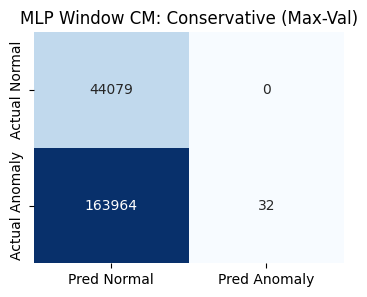


Window-level: Balanced (95th %)
Threshold: 0.1022
              precision    recall  f1-score   support

      Normal       0.21      0.96      0.35     44079
     Anomaly       0.84      0.05      0.10    163996

    accuracy                           0.25    208075
   macro avg       0.52      0.51      0.23    208075
weighted avg       0.70      0.25      0.15    208075



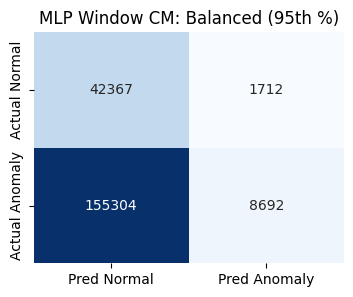


Cycle-level: Robust (Top-10% Mean)
Threshold: 0.1187
              precision    recall  f1-score   support

      Normal       0.06      1.00      0.11        48
     Anomaly       1.00      0.14      0.24       913

    accuracy                           0.18       961
   macro avg       0.53      0.57      0.18       961
weighted avg       0.95      0.18      0.24       961



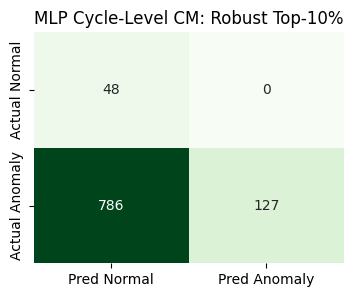

In [21]:
# Prepare data (flattening to 300 features)
model.eval()
reconstruction_list = []
X_test_flat = torch.FloatTensor(data['X_test']).reshape(-1, 300).to(device)

with torch.no_grad():
    for i in range(0, len(X_test_flat), 1024):
        batch = X_test_flat[i:i+1024]
        recon_batch = model(batch)
        reconstruction_list.append(recon_batch.cpu())

all_reconstructions = torch.cat(reconstruction_list, dim=0)

# Calculate MSE
mse_errors = torch.mean((X_test_flat.cpu() - all_reconstructions)**2, dim=1).numpy()
y_test = data['y_test']

# Mapping windows back to samples/cycles
window_to_sample_map = np.linspace(0, 960, len(mse_errors)).astype(int)

# Window-level evaluation
strategies_window = [
    ("Conservative (Max-Val)", 0.2801),
    ("Balanced (95th %)", np.percentile(mse_errors, 95))
]

for name, thresh in strategies_window:
    preds = (mse_errors > thresh).astype(int)
    print(f"\n{'='*40}\nWindow-level: {name}\nThreshold: {thresh:.4f}\n{'='*40}")
    print(classification_report(y_test, preds, target_names=['Normal', 'Anomaly']))

    # Plot
    cm = confusion_matrix(y_test, preds)
    plt.figure(figsize=(4,3))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=['Pred Normal', 'Pred Anomaly'],
                yticklabels=['Actual Normal', 'Actual Anomaly'])
    plt.title(f"MLP Window CM: {name}")
    plt.show()

# Cycle-level evaluation
results_df = pd.DataFrame({
    'sample_id': window_to_sample_map,
    'error': mse_errors,
    'true_label': y_test
})

# Robust Aggregation: average of top 10% worst windows per cycle
cycle_results_robust = results_df.groupby('sample_id').agg({
    'error': lambda x: x.nlargest(max(1, int(len(x) * 0.1))).mean(),
    'true_label': 'max'
})

# Calculate threshold for robust strategy based on normal cycles only
# add a tiny epsilon (0.001) to ensure the max normal cycle is included
thresh_robust = cycle_results_robust[cycle_results_robust['true_label'] == 0]['error'].max() + 0.001
preds_robust = (cycle_results_robust['error'] > thresh_robust).astype(int)

print(f"\n{'='*40}\nCycle-level: Robust (Top-10% Mean)\nThreshold: {thresh_robust:.4f}\n{'='*40}")
print(classification_report(cycle_results_robust['true_label'], preds_robust, target_names=['Normal', 'Anomaly']))

# Plot
cm_robust = confusion_matrix(cycle_results_robust['true_label'], preds_robust)
plt.figure(figsize=(4,3))
sns.heatmap(cm_robust, annot=True, fmt='d', cmap='Greens', cbar=False,
            xticklabels=['Pred Normal', 'Pred Anomaly'],
            yticklabels=['Actual Normal', 'Actual Anomaly'])
plt.title("MLP Cycle-Level CM: Robust Top-10%")
plt.show()

-----
-----
# MLP Autoencoder Model — Testing and Analysis

### 11. Model Evaluation

- **1. Window-level: Conservative failure (0% recall):** The model at threshold **0.2801** caught **zero** anomalies. This indicates the reconstruction error for anomalous windows falls within the distribution for normal operational noise. This failure is because MLP processes inputs as static flattened vectors, it lacks temporal dependency. If an anomaly is characterised by a specific sequence then the MLP will reconstruct the data too efficiently and mask the failure.

- **2. Window-level: Balanced (0.21 normal precision):** The 95th percentile threshold slightly increased sensitivity but resulted in a low precision at 0.21 because the model is predicting almost everything to be normal. Since the model defaults to a normal prediction due to a high threshold, it incorrectly classifies majority of the anomaly dataset and leads to a lopsided performance metric.

- **3. Cycle-level (14% recall):** The model focuses on separating the most difficult to reconstruct anomalies from standard noise. However, 86% of anomalies are undetected, meaning the normal and anomaly data are not distinguishable in the space of this autoencoder.

--- Final MLP Cycle Evaluation (N=961) ---
Strategy: Conservative Max-Val | Threshold: 0.2801
---------------------------------------------
              precision    recall  f1-score   support

      Normal       0.05      1.00      0.10        48
     Anomaly       1.00      0.01      0.01       913

    accuracy                           0.06       961
   macro avg       0.53      0.50      0.05       961
weighted avg       0.95      0.06      0.02       961



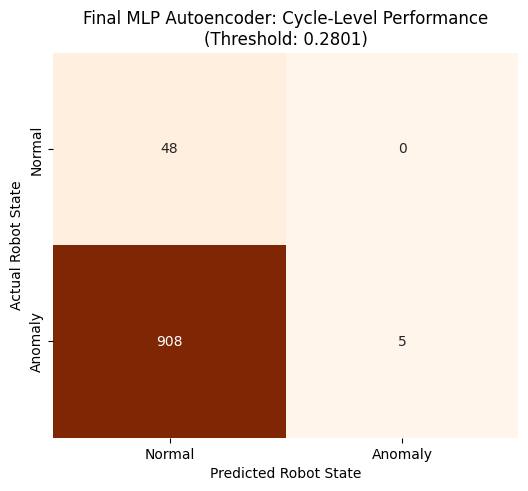

In [22]:
# Final system evaluation (cycle-level)

mlp_final_threshold = 0.2801 

# Prepare the cycle-level data
cycle_results_final = results_df.groupby('sample_id').agg({
    'error': 'max',
    'true_label': 'max'    # If any window in the cycle is anomalous, the cycle is anomalous
})

# Generate predictions
y_true_final = cycle_results_final['true_label']
y_pred_final = (cycle_results_final['error'] > mlp_final_threshold).astype(int)

# Display
print(f"--- Final MLP Cycle Evaluation (N={len(cycle_results_final)}) ---")
print(f"Strategy: Conservative Max-Val | Threshold: {mlp_final_threshold}")
print("-" * 45)
print(classification_report(y_true_final, y_pred_final, target_names=['Normal', 'Anomaly']))

# Save Confusion Matrix
plt.figure(figsize=(6, 5))
cm = confusion_matrix(y_true_final, y_pred_final)
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges', cbar=False,
            xticklabels=['Normal', 'Anomaly'],
            yticklabels=['Normal', 'Anomaly'])

plt.title(f'Final MLP Autoencoder: Cycle-Level Performance\n(Threshold: {mlp_final_threshold})')
plt.ylabel('Actual Robot State')
plt.xlabel('Predicted Robot State')
os.makedirs('../figures/mlp_autoencoder/', exist_ok=True)
plt.savefig('../figures/mlp_autoencoder/final_confusion_matrix.png', bbox_inches='tight')
plt.show()

Visualising a False Negative case ("hidden" anomaly that the MLP could not catch)

Analyzing False Negative Cycle ID: 658


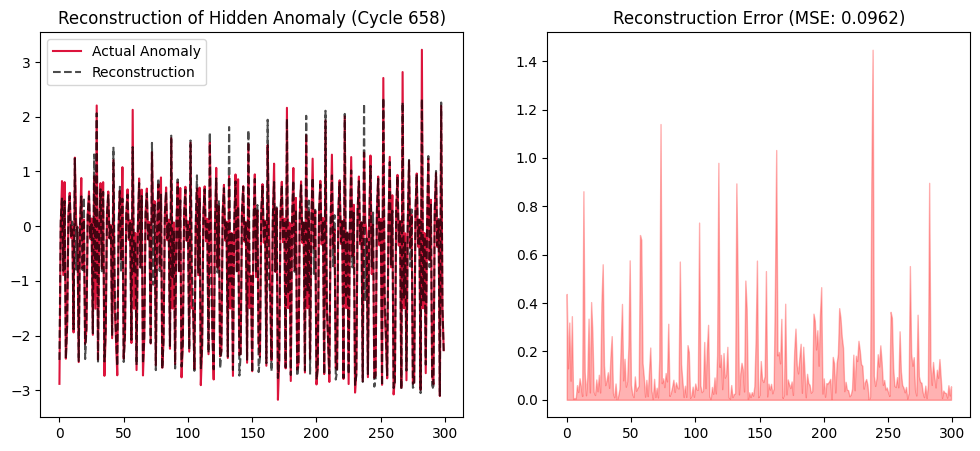

In [23]:
# Find a "hidden" anomaly (actual anomaly but predicted to be normal)
# We look for a cycle where label is 1 but max error was below our 0.2801 threshold
false_negatives = cycle_results_final[(cycle_results_final['true_label'] == 1) & 
                                      (cycle_results_final['error'] < mlp_final_threshold)]

# Pick the cycle with the lowest error among anomalies to show the most "invisible" case
target_cycle = false_negatives.sort_values(by='error').index[0]
print(f"Analyzing False Negative Cycle ID: {target_cycle}")

# Extract original vs reconstructed data for this cycle
target_indices = np.where(window_to_sample_map == target_cycle)[0]
original_sample = X_test_flat[target_indices[0]].cpu().numpy() # Take the first window of the cycle
reconstructed_sample = all_reconstructions[target_indices[0]].cpu().numpy()

# Plot
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(original_sample, label='Actual Anomaly', color='crimson')
plt.plot(reconstructed_sample, label='Reconstruction', color='black', linestyle='--', alpha=0.7)
plt.title(f'Reconstruction of Hidden Anomaly (Cycle {target_cycle})')
plt.legend()

plt.subplot(1, 2, 2)
diff = np.abs(original_sample - reconstructed_sample)
plt.fill_between(range(300), diff, color='red', alpha=0.3)
plt.title(f'Reconstruction Error (MSE: {false_negatives.loc[target_cycle, "error"]:.4f})')
plt.show()

### 12. Failure Case Analysis

**Visualising the invisble anomaly:** The primary failure of the MLP Autoencoder is its **inability to distinguish subtle anomalous sensor signatures from normal operational varianc**e. In the final evaluation (**threshold 0.2801**), the model produced a number of False Negatives which is where the robot malfunctions are classified as "Normal" (missed detections). The model prioritised industrial uptime over sensitivity.

**Visual Evidence for Cycle 658:**

- **Tracking:** The left plot shows the actual anomaly (red line) and the reconstruction (dotted black line). The lines are seen to mostly overlap each other throughout the entire window. The MLP is shown to over learned the sensor patterns and reconstructing the failure as if it was a healthy state.

- **Low residual error:** The right plot shows the absolute error. While there are spikes, the total MSE is only 0.0962.

- **Detectoin gap:** Because 0.0962 << 0.2801, this cycle is indistinguishable from the training data. This proves the anomaly does not manifest as out of bounds value but a subtle pattern that the autoencoder is too robust to detect.

**Why the conservative strategy failed:**
In a zero false alarm setup, we set the bar based on the noisiest normal sample. Cycle 658 proves that a quiet anomaly can look more normal than a noisy healthy cycle. This model created a safety buffer for production but also a blind spot for any malfunction that generates a reconstruction error lower than the model's worst case healthy performance.

-----
### (Optional) Reproducibility

This cell allows for loading of saved model weights without retraining the model.

**Requirements for loading successfully:**

- The `MLPAutoencoder` class definition must be present in the environment and match the saved `.pth` file.
- Weights must be mapped to the current `device` (CUDA or CPU) before or during loading to ensure hardware compatibilty
- Model must be set to `eval()` mode for disabling dropout layers and ensure consistent reconstruction results during testing.
- Ensure input data to be flattened to a 300 feature vector and transformed using saved `scalar.pkl` before being passed to the model.

In [24]:
'''
For quick test loading without retraining (or for use in a new notebook)

run the following lines:
'''

# Recreate the structure
test_model = MLPAutoencoder(input_dim=300).to(device)

# Load weights
try:
    # map_location ensures it works even if trained on GPU but loaded on CPU
    test_model.load_state_dict(torch.load(MLPAUTO_MODEL_PATH, map_location=device))
    
    # Set to evaluation mode
    test_model.eval()
    print(f"MLP Model successfully loaded from {MLPAUTO_MODEL_PATH}")
    print(f"Current Device: {device}")
except FileNotFoundError:
    print("Error: .pth file not found. Check your /model directory.")

MLP Model successfully loaded from ..\model\mlp_autoencoder\mlp_autoencoder.pth
Current Device: cuda
